In [1]:
%load_ext autoreload
%autoreload 2
from L96 import *
from sklearn.decomposition import PCA
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib
from hmmlearn.hmm import GaussianHMM
from scipy.stats import gaussian_kde
from scipy.special import rel_entr
import pickle
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
def get_X(path=None, model_name='NN+AE'):
    if not path:
        il = 0 if model_name == 'baseline_nn' else 1000
        #il = 0 if model_name == 'baseline_nn' else 500
        #path = f'online_runs/{model_name}/input_lagg={il}/time=5000000_m=0.001_tau=0.001.pkl'
        path = f'online_runs/{model_name}/input_lagg={il}/time=50000000_m=0.001_tau=0.001.pkl'
    if '.nc' in path:
        L96 = L962LvlMem()
        XB = xr.load_dataset(path)
        L96._history_X = XB.X
        L96._history_B = XB.B
    else:
        with open(path, 'rb') as file:
                L96 = pickle.load(file)
            
    m = float(re.search(r'm=([\d.]+)', path).group(1))
    tau = float(re.search(r'tau=([\d.]+)', path).group(1)[:-1])
    #title = f'm={round(m, 3)}, tau={round(tau, 3)}'
    X = L96.history.X.values
    # print(L96.dt, L96.save_dt)
    X = X[::5, :]

    return X

In [3]:
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.
    
        cmap: colormap instance, eg. cm.jet. 
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0.,0.,0.,0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red','green','blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1,ki], colors_rgba[i,ki]) for i in range(N+1)]
    # Return colormap object.
    return matplotlib.colors.LinearSegmentedColormap(cmap.name + "_%d"%N, cdict, 1024)

discretized_jet = cmap_discretize(matplotlib.cm.jet, 15)

def plot_regimes(X, title, fig=None, ax=None, true_PDF=None, xbins=None, ybins=None):
    smoothed_data = uniform_filter1d(X, size=80, axis=0)
    pca_smooth = PCA(n_components=4)
    pca_data_smooth = pca_smooth.fit_transform(smoothed_data)
    print(title, ' Explained variance per PC: ', pca_smooth.explained_variance_ratio_)
    dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
    dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

    if fig and ax:
        pass    
    else:
        fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
    if xbins is None:
        bins=350
    else:
        bins = [xbins, ybins]
    PDF, xbins, ybins, im = ax.hist2d(x=dim1,y=dim2,bins=bins,cmap=discretized_jet,density=True, vmin=0, vmax=.08)  #0.06786
    kl_div = None
    if true_PDF is not None:
        # kl_div = np.sum(rel_entr(true_PDF + 1e-10, PDF + 1e-10))
        mask = (true_PDF > 0)
        kl_div = np.sum(rel_entr(true_PDF[mask], PDF[mask] + 1e-12))
        print(f"KL Divergence: {kl_div:.4f}")
    # ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', xlim=(1,14), ylim=(0,10), title=title)
    # fig.colorbar(im, ax=ax)
    # print(im[3].norm.vmax)

    return fig, ax, PDF, kl_div, im, xbins, ybins

In [4]:
path_true = 'online_runs/NO_PARAMETRIZATION/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
path_memory = 'online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
#path_memory_ODE = 'online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
path_memory_ODE = 'online_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202606021417.nc'
path_base = 'online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'
path_base_nonlocal = 'online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'
paths = [path_true, path_memory, path_memory_ODE, path_base, path_base_nonlocal]
titles = ['True', 'autoencoder', 'linear\n ODE', 'baseline', 'non-local\n baseline']

In [5]:
FS = 12
plt.rcParams.update({
    "font.size": FS,              # base font size
    "axes.labelsize": FS,         # x/y labels
    "xtick.labelsize": FS,        # x tick labels
    "ytick.labelsize": FS,        # y tick labels
    "legend.fontsize": FS,        # legend
    'axes.linewidth': 0.8,
    'lines.linewidth': 2.0
})

True  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
autoencoder  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
  linear
  ODE  Explained variance per PC:  [0.33548534 0.33542168 0.07713122 0.07700162]
KL Divergence: 24.2032
baseline  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
 non-local
 baseline  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


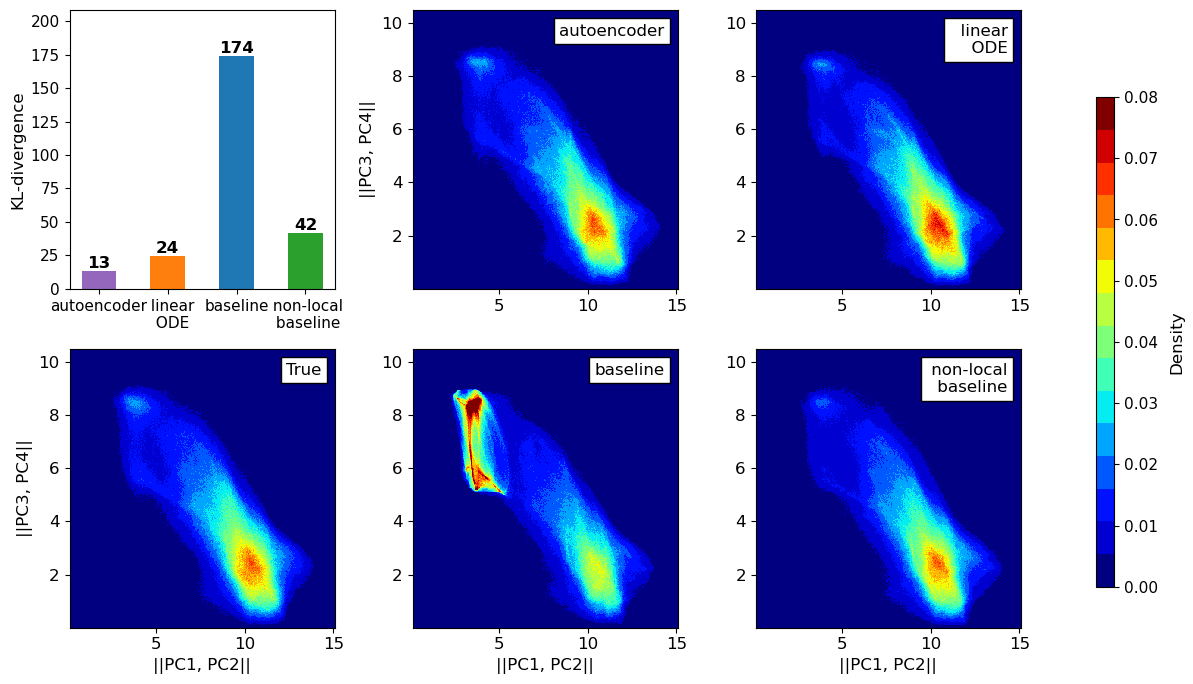

In [6]:
import matplotlib.pyplot as plt
import numpy as np
titles = ['True', 'autoencoder', '  linear\n  ODE', 'baseline', ' non-local\n baseline']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

# ----------------------
# Axis assignment (NEW)
# ----------------------
ax_kl = axes[0]
ax_gt = axes[3]
model_axes = [axes[1], axes[2], axes[4], axes[5]]

# ----------------------
# 1) Ground truth (compute FIRST)
# ----------------------
X = get_X(path=paths[0])
_, _, true_PDF, _, im_gt, xbins, ybins = plot_regimes(
    X,
    title=titles[0],
    fig=fig,
    ax=ax_gt
)

ax_gt.text(
    0.95, 0.95, titles[0],
    transform=ax_gt.transAxes,
    ha='right', va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

# ----------------------
# 2) Models
# ----------------------
kl_values = []
ims = []

for ax, path, title in zip(model_axes, paths[1:], titles[1:]):
    X = get_X(path=path)
    _, _, _, kl_div, im, _, _ = plot_regimes(
        X,
        title=title,
        fig=fig,
        ax=ax,
        true_PDF=true_PDF,
        xbins=xbins,
        ybins=ybins
    )

    kl_values.append(kl_div)
    ims.append(im)

    ax.text(
        0.95, 0.95,
        f"{title}",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', edgecolor='black')
    )

# ----------------------
# 3) KL bar plot
# ----------------------
# Create bars and store container for labeling
model_names = titles[1:]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:green']
bars = ax_kl.bar(model_names, kl_values, color=colors, width=.5)

# Add KL values on top of each bar
for bar, kl_val in zip(bars, kl_values):
    height = bar.get_height()
    
    # Format value based on magnitude
    if kl_val < 10:
        label_text = f'{kl_val:.2f}'
    else:
        label_text = f'{kl_val:.0f}'
    
    ax_kl.text(
        bar.get_x() + bar.get_width() / 2,  # x-position (center of bar)
        height,                              # y-position (top of bar)
        label_text,                          # text to display
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=FS,                          # font size
        fontweight='bold'                    # make it stand out
    )

ax_kl.set_ylabel("KL-divergence", fontsize=FS)
ax_kl.set_xticks(range(len(model_names)))
ax_kl.set_xticklabels(model_names, fontsize=FS - 1)
ax_kl.tick_params(axis='both', labelsize=FS-1)

# Add space above bars for labels
ax_kl.set_ylim(0, max(kl_values) * 1.20)  # 20% extra space

# ----------------------
# Axis labels
# ----------------------
# Bottom row → x labels
for ax in axes[3:]:
    ax.set_xlabel("||PC1, PC2||")

# Left column (EXCLUDING KL plot)
for ax in [axes[3]]:  # only GT now
    ax.set_ylabel("||PC3, PC4||")

# Also apply to top-left model (axes[1])
axes[1].set_ylabel("||PC3, PC4||")

# ----------------------
# Layout + Colorbar
# ----------------------
# ----------------------
# Layout + Colorbar
# ----------------------
plt.tight_layout(rect=[0, 0, 0.88, 1])  # Even more space on right

cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # Move from 0.94 → 0.92
cbar = fig.colorbar(im_gt, cax=cax)
cbar.set_label("Density", fontsize=FS, labelpad=8)  # Increase labelpad
cax.tick_params(labelsize=FS-1)

plt.savefig('L96_regime_analysis.png', bbox_inches='tight', dpi=300)

True  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
autoencoder  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
linear ODE  Explained variance per PC:  [0.34473297 0.34419566 0.06859802 0.06838235]
KL Divergence: 56.4616
baseline  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
non-local baseline  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


/tmp/ipykernel_142875/707114339.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


TypeError: Colorbar.__init__() got an unexpected keyword argument 'fontsize'

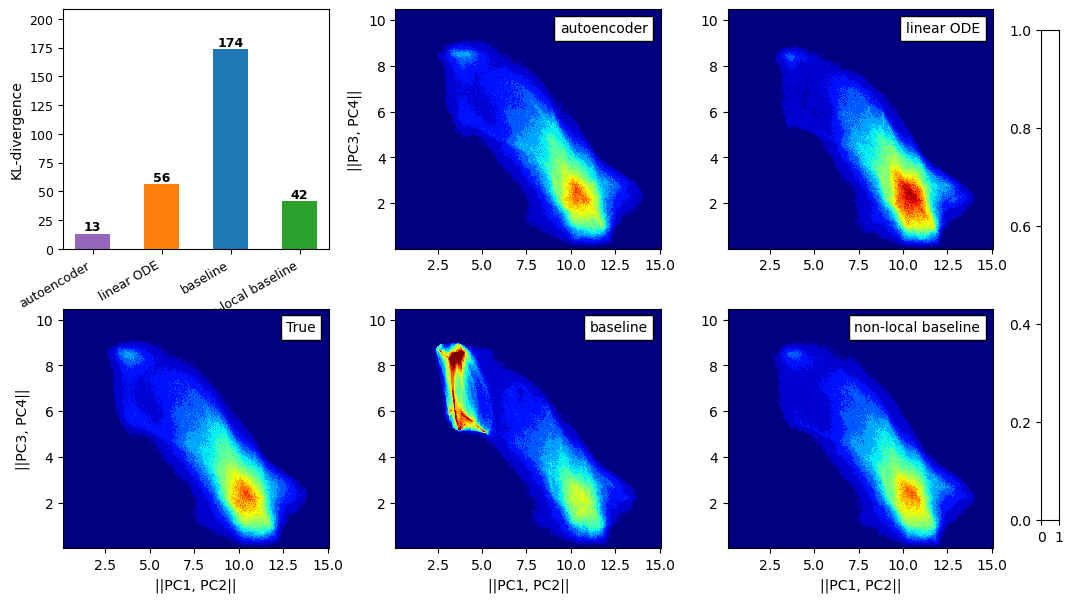

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2, 3, 
    figsize=(12, 7),
    gridspec_kw={'hspace': 0.25, 'wspace': 0.25}  # Reduced vertical spacing
)
axes = axes.flatten()

# ----------------------
# Axis assignment (NEW)
# ----------------------
ax_kl = axes[0]
ax_gt = axes[3]
model_axes = [axes[1], axes[2], axes[4], axes[5]]

# ----------------------
# 1) Ground truth (compute FIRST)
# ----------------------
X = get_X(path=paths[0])
_, _, true_PDF, _, im_gt, xbins, ybins = plot_regimes(
    X,
    title=titles[0],
    fig=fig,
    ax=ax_gt
)

ax_gt.text(
    0.95, 0.95, titles[0],
    transform=ax_gt.transAxes,
    ha='right', va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

# ----------------------
# 2) Models
# ----------------------
kl_values = []
ims = []

for ax, path, title in zip(model_axes, paths[1:], titles[1:]):
    X = get_X(path=path)
    _, _, _, kl_div, im, _, _ = plot_regimes(
        X,
        title=title,
        fig=fig,
        ax=ax,
        true_PDF=true_PDF,
        xbins=xbins,
        ybins=ybins
    )

    kl_values.append(kl_div)
    ims.append(im)

    ax.text(
        0.95, 0.95,
        f"{title}",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', edgecolor='black')
    )

# ----------------------
# 3) KL bar plot with value labels
# ----------------------
model_names = titles[1:]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:green']

# Create bars and store container for labeling
bars = ax_kl.bar(model_names, kl_values, color=colors, width=.5)

# Add KL values on top of each bar
for bar, kl_val in zip(bars, kl_values):
    height = bar.get_height()
    
    # Format value based on magnitude
    if kl_val < 10:
        label_text = f'{kl_val:.2f}'
    else:
        label_text = f'{kl_val:.0f}'
    
    ax_kl.text(
        bar.get_x() + bar.get_width() / 2,  # x-position (center of bar)
        height,                              # y-position (top of bar)
        label_text,                          # text to display
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=9,                          # font size
        fontweight='bold'                    # make it stand out
    )

ax_kl.set_ylabel("KL-divergence", fontsize=10)
ax_kl.set_xticks(range(len(model_names)))
ax_kl.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax_kl.tick_params(axis='both', labelsize=9)

# Add space above bars for labels
ax_kl.set_ylim(0, max(kl_values) * 1.20)  # 20% extra space

# ----------------------
# Axis labels
# ----------------------
# Bottom row → x labels
for ax in axes[3:]:
    ax.set_xlabel("||PC1, PC2||", fontsize=10)

# Left column (EXCLUDING KL plot)
for ax in [axes[3]]:  # only GT now
    ax.set_ylabel("||PC3, PC4||", fontsize=10)

# Also apply to top-left model (axes[1])
axes[1].set_ylabel("||PC3, PC4||", fontsize=10)

# ----------------------
# Layout + Colorbar
# ----------------------
plt.tight_layout(rect=[0, 0, 0.92, 1])

cax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im_gt, cax=cax, label="Density")

plt.show()

In [8]:
kl_values

[None, None, None, None]

true  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
$\phi_{8,1}$  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
$\phi_{8,1,ED}$  Explained variance per PC:  [0.34473297 0.34419566 0.06859802 0.06838235]
KL Divergence: 56.4616
$\phi_{0,0}$  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
$\phi_{0,0,\text{non-local}}$  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


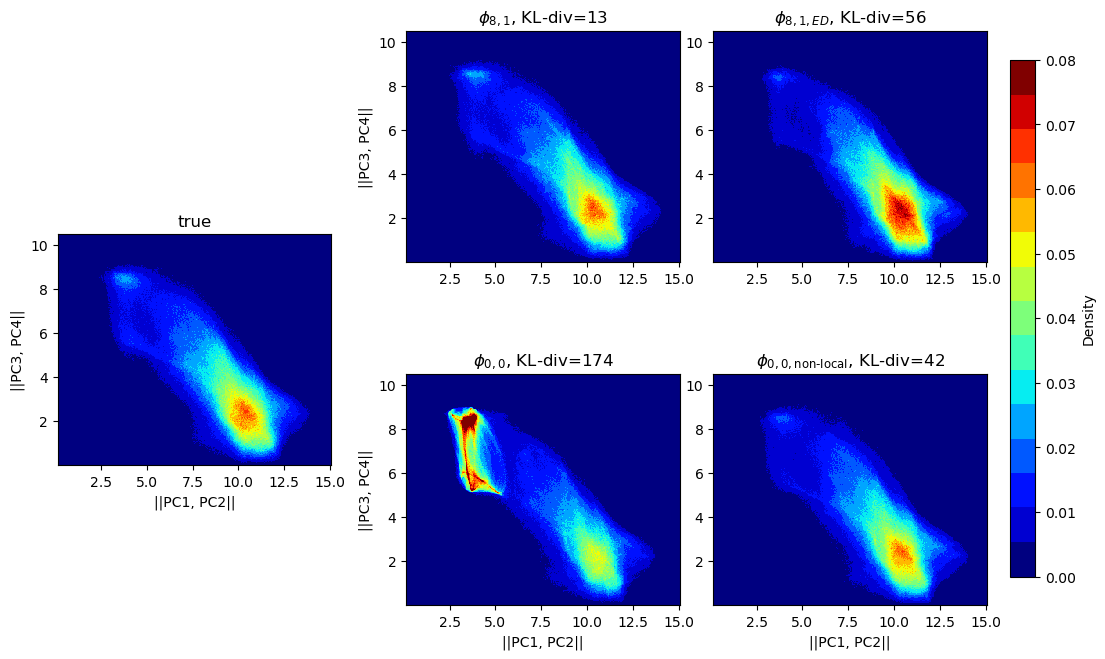

In [ ]:
fig = plt.figure(figsize=(10,7))  # no constrained_layout

# --- Model axes positions (right side 2 columns) ---
# We manually position all axes in figure coordinates [x0, y0, width, height]
# Let's assume: left 30% of width for GT, right 70% split into 2 columns

panel_width = 0.33
panel_height = 0.33
x_start_models = 0.36  # right-hand start for 2x2 grid
y_top = 0.64
y_bottom = 0.15
x_spacing = 0.04
y_spacing = 0.05

ax_m1 = fig.add_axes([x_start_models, y_top, panel_width, panel_height])
ax_m2 = fig.add_axes([x_start_models + panel_width + x_spacing, y_top, panel_width, panel_height])
ax_m3 = fig.add_axes([x_start_models, y_bottom, panel_width, panel_height], sharex=ax_m1, sharey=ax_m1)
ax_m4 = fig.add_axes([x_start_models + panel_width + x_spacing, y_bottom, panel_width, panel_height], sharex=ax_m1, sharey=ax_m1)

model_axes = [ax_m1, ax_m2, ax_m3, ax_m4]

# --- Ground truth axis (left) ---
x0_gt = -0.06
y0_gt = 0.35  # vertically centered
width_gt = panel_width
height_gt = panel_height
ax_gt = fig.add_axes([x0_gt, y0_gt, width_gt, height_gt], sharex=ax_m1, sharey=ax_m1)

# ----------------------
# Ground truth
# ----------------------
X = get_X(path=paths[0])
_, _, true_PDF, _, im_gt, xbins, ybins = plot_regimes(
    X,
    title=titles[0],
    fig=fig,
    ax=ax_gt
)
ax_gt.set_title(titles[0])

# ----------------------
# Models
# ----------------------
ims = []
for ax, path, title in zip(model_axes, paths[1:], titles[1:]):
    X = get_X(path=path)
    _, _, _, kl_div, im, _, _ = plot_regimes(
        X,
        title=title,
        fig=fig,
        ax=ax,
        true_PDF=true_PDF,
        xbins=xbins,
        ybins=ybins
    )
    ims.append(im)
    ax.set_title(f"{title}, KL-div={round(kl_div)}")

# ----------------------
# Shared colorbar
# ----------------------
fig.colorbar(im_gt, ax=[ax_gt] + model_axes, shrink=0.9, pad=0.02, label="Density")

# ----------------------
# Axis labels
# ----------------------
for ax in [ax_m3, ax_m4, ax_gt]:
    ax.set_xlabel("||PC1, PC2||")
for ax in [ax_m1, ax_m3, ax_gt]:
    ax.set_ylabel("||PC3, PC4||")

true  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
$\phi_{8,1}$  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
$\phi_{8,1,ED}$  Explained variance per PC:  [0.34473297 0.34419566 0.06859802 0.06838235]
KL Divergence: 56.4616
$\phi_{0,0}$  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
$\phi_{0,0,\text{non-local}}$  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


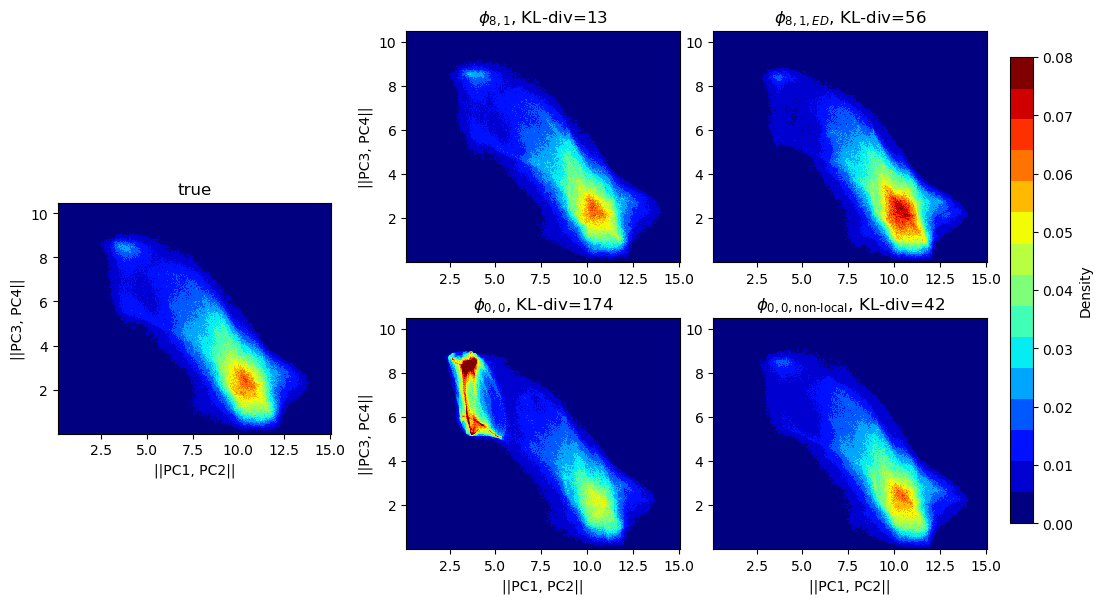

In [59]:
fig = plt.figure(figsize=(10,7))  # no constrained_layout

# --- panel sizes ---
panel_width = 0.33
panel_height = 0.33
x_spacing = 0.04
gap_vertical = 0.08  # smaller gap between rows

# --- right-hand 2x2 grid positions ---
x_start_models = 0.36
y_top = 0.6                       # row 1 top
y_bottom = y_top - panel_height - gap_vertical  # row 2 closer to row 1

ax_m1 = fig.add_axes([x_start_models, y_top, panel_width, panel_height])
ax_m2 = fig.add_axes([x_start_models + panel_width + x_spacing, y_top, panel_width, panel_height])
ax_m3 = fig.add_axes([x_start_models, y_bottom, panel_width, panel_height], sharex=ax_m1, sharey=ax_m1)
ax_m4 = fig.add_axes([x_start_models + panel_width + x_spacing, y_bottom, panel_width, panel_height], sharex=ax_m1, sharey=ax_m1)

model_axes = [ax_m1, ax_m2, ax_m3, ax_m4]

# --- Ground truth axis (left) ---
x0_gt = -0.06
y0_gt = y_bottom + (panel_height)/2  # vertically centered between top and bottom row
ax_gt = fig.add_axes([x0_gt, y0_gt, panel_width, panel_height], sharex=ax_m1, sharey=ax_m1)

# ----------------------
# Ground truth
# ----------------------
X = get_X(path=paths[0])
_, _, true_PDF, _, im_gt, xbins, ybins = plot_regimes(
    X,
    title=titles[0],
    fig=fig,
    ax=ax_gt
)
ax_gt.set_title(titles[0])

# ----------------------
# Models
# ----------------------
ims = []
for ax, path, title in zip(model_axes, paths[1:], titles[1:]):
    X = get_X(path=path)
    _, _, _, kl_div, im, _, _ = plot_regimes(
        X,
        title=title,
        fig=fig,
        ax=ax,
        true_PDF=true_PDF,
        xbins=xbins,
        ybins=ybins
    )
    ims.append(im)
    ax.set_title(f"{title}, KL-div={round(kl_div)}")

# ----------------------
# Shared colorbar
# ----------------------
fig.colorbar(im_gt, ax=[ax_gt] + model_axes, shrink=0.9, pad=0.02, label="Density")

# ----------------------
# Axis labels
# ----------------------
for ax in [ax_m3, ax_m4, ax_gt]:
    ax.set_xlabel("||PC1, PC2||")
for ax in [ax_m1, ax_m3, ax_gt]:
    ax.set_ylabel("||PC3, PC4||")

true  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
$\phi_{8,1}$  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
$\phi_{8,1,ED}$  Explained variance per PC:  [0.34473297 0.34419566 0.06859802 0.06838235]
KL Divergence: 56.4616
$\phi_{0,0}$  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
$\phi_{0,0,\text{non-local}}$  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


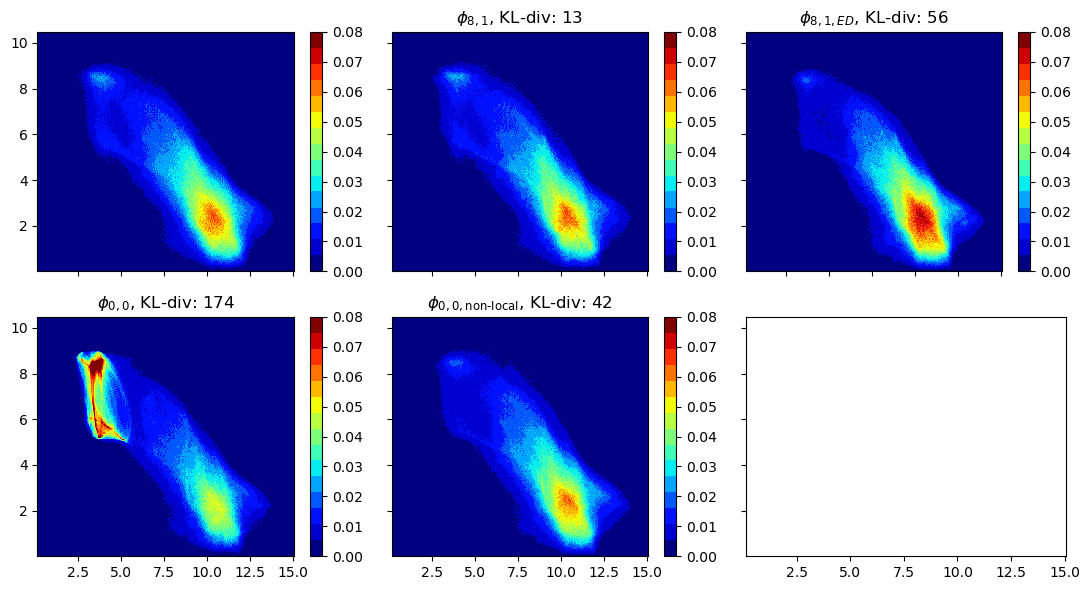

In [33]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(11,6), sharex=True, sharey=True)
ground_truth = True
for ax, path, title in zip(axs.flatten(), paths, titles):
    X = get_X(path=path)
    if ground_truth:
        _, _, true_PDF, _, xbins, ybins = plot_regimes(X, title=title, fig=fig, ax=ax)
        ground_truth = False
    else:
        _, _, _, kl_div, _, _ = plot_regimes(X, title=title, fig=fig, ax=ax, 
                                             true_PDF=true_PDF, xbins=xbins, ybins=ybins)
        ax.set_title(f"{title}, KL-div: {round(kl_div)}")

plt.tight_layout()

Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$true$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

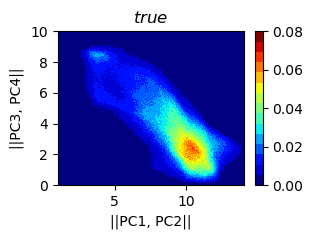

In [27]:
plot_regimes(get_X(path=path_true), 
             title=r'$true$')

Explained variance per PC:  [0.34473297 0.34419566 0.06859802 0.06838235]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{8,1,1,ODE}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

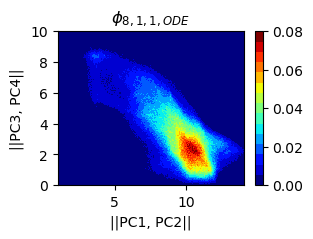

In [28]:
plot_regimes(get_X(path='online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'), title=r'$\phi_{8,1,1,ODE}$')

Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{8,1,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

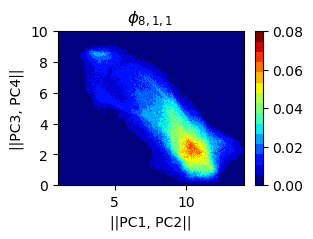

In [29]:
plot_regimes(get_X(path='online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'), title=r'$\phi_{8,1,1}$')

Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{0,0,8}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

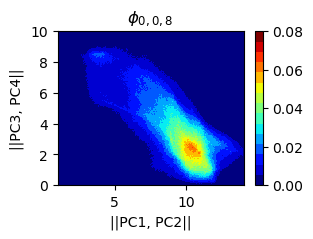

In [30]:
plot_regimes(get_X(path='online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'), 
             title=r'$\phi_{0,0,8}$')

Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{0,0,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

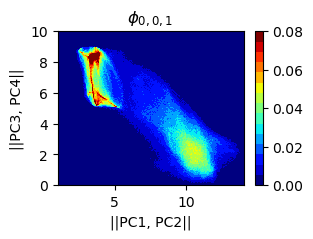

In [31]:
plot_regimes(get_X(path='online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'), title=r'$\phi_{0,0,1}$')

In [13]:
smoothed_data = uniform_filter1d(X, size=80, axis=0)

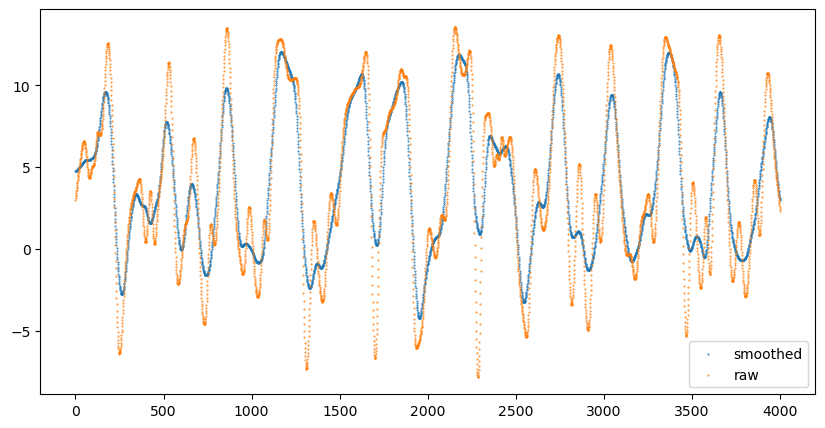

In [14]:
fig,ax = plt.subplots(figsize=(10,5),nrows=1,ncols=1)
ax.scatter(np.arange(0,4000),smoothed_data[:4000,1],s=0.2,label="smoothed")
ax.scatter(np.arange(0,4000),X[:4000,1],s=0.2,label="raw")
ax.legend()

In [15]:
pca_smooth = PCA(n_components=4)
pca_data_smooth = pca_smooth.fit_transform(smoothed_data)

In [16]:
smoothed_data.shape

(2000000, 8)

In [17]:
pca_smooth.explained_variance_ratio_

array([0.3322601 , 0.33188603, 0.08106696, 0.08060642])

In [18]:
dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

In [19]:
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.
    
        cmap: colormap instance, eg. cm.jet. 
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0.,0.,0.,0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red','green','blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1,ki], colors_rgba[i,ki]) for i in range(N+1)]
    # Return colormap object.
    return matplotlib.colors.LinearSegmentedColormap(cmap.name + "_%d"%N, cdict, 1024)

In [20]:
discretized_jet = cmap_discretize(matplotlib.cm.jet, 15)
discretized_virids = cmap_discretize(matplotlib.cm.viridis, 15)

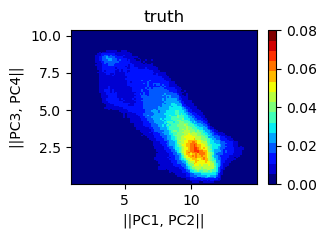

In [24]:
fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
im = ax.hist2d(x=dim1,y=dim2,bins=100,cmap=discretized_jet,density=True, vmin=0, vmax=0.08)
ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', title=title)
fig.colorbar(im[3], ax=ax)

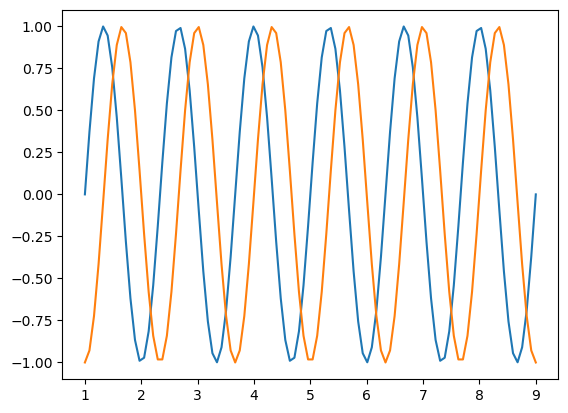

In [129]:
K = 8
Ks = np.linspace(1, K+1, 100)
for j in range(6, 7):
    s = np.cos(2 * np.pi * j * Ks /K )
    c = np.sin(2 * np.pi * j * Ks /K )
    plt.plot(Ks, s, label=f'j={j}')
    plt.plot(Ks, c, label=f'j={j}')


In [205]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import normalize
from hmmlearn.hmm import GaussianHMM

In [219]:
# Assuming X is your input array with shape (NT, K=8)
NT, K = X.shape
assert K == 8, "This version expects 8 L96 variables."

# Step 1: Anomalize
X_anom = X - np.mean(X, axis=0, keepdims=True)

# Step 2: Project into circular sine/cosine basis
u, v = [], []
for j in range(1, 5):
    s = np.cos(2 * np.pi * j * np.arange(K) / K)
    c = np.sin(2 * np.pi * j * np.arange(K) / K)
    s /= np.linalg.norm(s)
    c /= np.linalg.norm(c)
    u.append(X_anom @ s)
    v.append(X_anom @ c)

# Step 3: Compute radial coordinates (magnitude in each phase angle)
X_proj = np.sqrt(np.array(u)**2 + np.array(v)**2).T  # shape: (NT, 4)

# Step 4: Fit 2-cluster GMM
nclust = 2
gmm = GaussianMixture(n_components=nclust, max_iter=500, random_state=2)
gmm.fit(X_proj)

# Step 5: Initialize and fit HMM
hmm = GaussianHMM(n_components=nclust, covariance_type='full', n_iter=50, random_state=2)
hmm.startprob_ = normalize(np.random.rand(1, nclust))[0]
hmm.transmat_ = normalize(np.random.rand(nclust, nclust), axis=1)
hmm.means_ = gmm.means_
hmm.covars_ = gmm.covariances_

hmm.fit(X_proj)

# Step 6: Decode regime sequence
states = hmm.predict(X_proj)

# Optional: View results
print("Inferred transition matrix:\n", hmm.transmat_)
print("Regime time series (first 20):", states[:20])


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Inferred transition matrix:
 [[0.98804713 0.01195287]
 [0.01044238 0.98955762]]
Regime time series (first 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# 7. KDE for full distribution and each regime
def kde_2d(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    X, Y = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(coords).reshape(X.shape)
    return X, Y, Z

# Use the first 2 components for 2D KDE
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Grid setup
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# KDEs
X1, Y1, Z_all = kde_2d(X2d, x_grid, y_grid)
_, _, Z_1 = kde_2d(pts1, x_grid, y_grid)
_, _, Z_2 = kde_2d(pts2, x_grid, y_grid)

# Normalize by regime size
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)

# 8. Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, Z, title in zip(axs, [Z_all, Z_1, Z_2], ['All Points', 'Regime 1', 'Regime 2']):
    c = ax.contourf(X1, Y1, Z, levels=30, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Z_1')
    ax.set_ylabel('Z_2')
    fig.colorbar(c, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
# 7. KDE
def kde_contour_data(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    Xg, Yg = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([Xg.ravel(), Yg.ravel()])
    Z = kde(coords).reshape(Xg.shape)
    return Xg, Yg, Z

# Use first 2 components for 2D
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Grid
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# Contours
Xg, Yg, Z_all = kde_contour_data(X2d, x_grid, y_grid)
_, _, Z_1 = kde_contour_data(pts1, x_grid, y_grid)
_, _, Z_2 = kde_contour_data(pts2, x_grid, y_grid)

# Normalize regime-specific KDEs
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)

In [220]:
# KDE function
def kde_contour_data(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    Xg, Yg = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([Xg.ravel(), Yg.ravel()])
    Z = kde(coords).reshape(Xg.shape)
    return Xg, Yg, Z

# Sampling helper function
def sample_data(x, max_points=5000):
    if len(x) > max_points:
        idx = np.random.choice(len(x), max_points, replace=False)
        return x[idx]
    return x

# Use first 2 components for 2D
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Sampled subsets for faster KDE
X2d_sampled = sample_data(X2d)
pts1_sampled = sample_data(pts1)
pts2_sampled = sample_data(pts2)

# Grid
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# Contours
Xg, Yg, Z_all = kde_contour_data(X2d_sampled, x_grid, y_grid)
_, _, Z_1 = kde_contour_data(pts1_sampled, x_grid, y_grid)
_, _, Z_2 = kde_contour_data(pts2_sampled, x_grid, y_grid)

# Normalize regime-specific KDEs
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)


/tmp/ipykernel_1862073/2832900052.py:4: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_all, levels=Nlevels, colors='gray', linestyles='dashed', linewidths=1, label='Unconditional')
/tmp/ipykernel_1862073/2832900052.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_1, levels=Nlevels, colors='blue', linewidths=1.5, label='Regime 1')
/tmp/ipykernel_1862073/2832900052.py:6: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_2, levels=Nlevels, colors='red', linewidths=1.5, label='Regime 2')


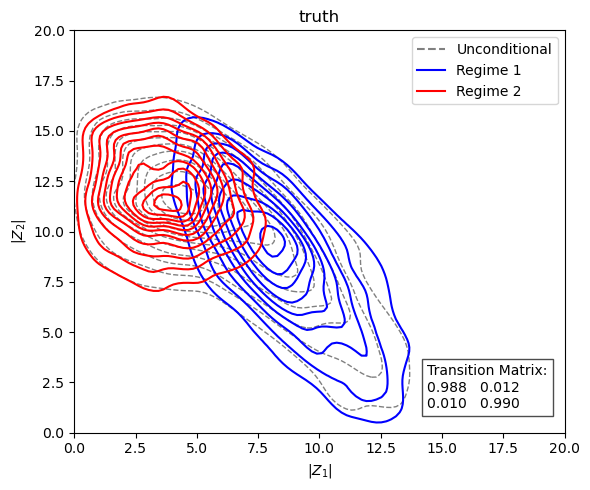

In [221]:
# 8. Plot
plt.figure(figsize=(6, 5))
Nlevels = 11
plt.contour(Xg, Yg, Z_all, levels=Nlevels, colors='gray', linestyles='dashed', linewidths=1, label='Unconditional')
plt.contour(Xg, Yg, Z_1, levels=Nlevels, colors='blue', linewidths=1.5, label='Regime 1')
plt.contour(Xg, Yg, Z_2, levels=Nlevels, colors='red', linewidths=1.5, label='Regime 2')

# Labels
plt.xlabel(r'$|Z_1|$')
plt.ylabel(r'$|Z_2|$')
plt.title(title)
plt.grid(False)

# Custom legend since plt.contour doesn't create one directly
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color='gray', linestyle='--', label='Unconditional'),
    Line2D([0], [0], color='blue', label='Regime 1'),
    Line2D([0], [0], color='red', label='Regime 2')
]
plt.legend(handles=legend_lines)

# Add transition matrix text
transmat_text = '\n'.join(
    [f"{row[0]:.3f}   {row[1]:.3f}" for row in hmm.transmat_]
)
plt.text(0.72, 0.17, f"Transition Matrix:\n{transmat_text}",
         transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))


plt.tight_layout()
plt.show()